# Cáncer colorrectal en personas de 50 años o menos: qué dicen los datos GRD de Chile (2019-2024)

En 2024 y 2025 varios medios y sociedades científicas chilenas reportaron algo llamativo:
Chile estaría entre los países con mayor aumento mundial de cáncer colorrectal en menores
de 50 años en la última década. Este notebook usa el registro público de egresos
hospitalarios GRD (FONASA) para revisar esa afirmación con datos propios, no para
confirmarla ni refutarla de antemano.

**Pregunta:** ¿la tasa de hospitalizaciones por cáncer colorrectal en personas de 50 años
o menos viene subiendo más rápido que en el resto de la población, y qué tan sólida es esa
señal?

Fuentes usadas:
- **GRD público 2019-2024** ([FONASA](https://datosabiertos.fonasa.cl)): egresos
  hospitalarios y cirugía mayor ambulatoria (CMA) con diagnóstico principal de cáncer
  colorrectal (CIE-10 C18, C19, C20), y de tres categorías relacionadas extraídas aparte:
  cáncer de ano (C21), carcinoma in situ (D01) y pólipos adenomatosos (D12.6).
- **Estimaciones y proyecciones de población del INE** (base 2017, cuadro comunal agregado
  a nivel país) por edad simple y año, para calcular tasas por 100.000 habitantes en vez de
  solo contar casos (la población de Chile creció ~5% entre 2019 y 2024, así que contar
  casos sin más ya exagera cualquier tendencia).

## Qué es y qué NO es este dataset

GRD es un registro de **egresos hospitalarios y cirugía mayor ambulatoria (CMA)**
publicado por FONASA, no un registro poblacional de cáncer:

- Solo capta personas con un episodio de hospitalización o CMA con ese diagnóstico
  principal. Alguien diagnosticado y tratado solo de forma ambulatoria (consulta,
  quimioterapia sin cirugía), no aparece acá.
- Cubre los 72 hospitales financiados por el mecanismo de pago GRD: la red pública y
  clínicas en convenio. Dentro de esos hospitales, el 99% de las admisiones extraídas son
  de previsión FONASA. No representa a la población atendida 100% en el sistema privado
  (ISAPRE).
- El número de esos hospitales que reportaron casos de cáncer colorrectal **creció de 59 a
  67** entre 2019 y 2024 (+13,6%), lo que por sí solo ya explicaría parte de cualquier
  aumento en el conteo bruto de casos. Por eso el análisis usa tasas por 100.000
  habitantes, no solo conteos, aunque el crecimiento en cobertura de hospitales sigue
  siendo una limitación a tener en cuenta.
- El identificador de paciente encriptado sirve para deduplicar dentro de un mismo año,
  pero no para seguir a la misma persona entre años (el sistema de encriptación cambió
  entre archivos).

Con esas salvedades, es igualmente el mejor registro público disponible para mirar esta
pregunta con datos reales de Chile.

In [1]:
import sys
sys.path.insert(0, "src")

import analisis_utils as au
from estilo_graficos import aplicar_estilo, PALETA
import matplotlib.pyplot as plt
import numpy as np

aplicar_estilo()

df, pop_grupo = au.cargar_datos()
tasas = au.tasas_por_anio(df, pop_grupo)

print(f"Total de admisiones extraídas (2019-2024): {len(df):,}")
print(df.categoria_clinica.value_counts())

Total de admisiones extraídas (2019-2024): 33,661
categoria_clinica
cancer_colorrectal    32180
cancer_ano              963
polipo_adenomatoso      406
carcinoma_in_situ       112
Name: count, dtype: int64


## 1. La tendencia general: la tasa sube en ambos grupos, pero no al mismo ritmo

Cáncer colorrectal (C18-C20) como diagnóstico principal de la hospitalización.

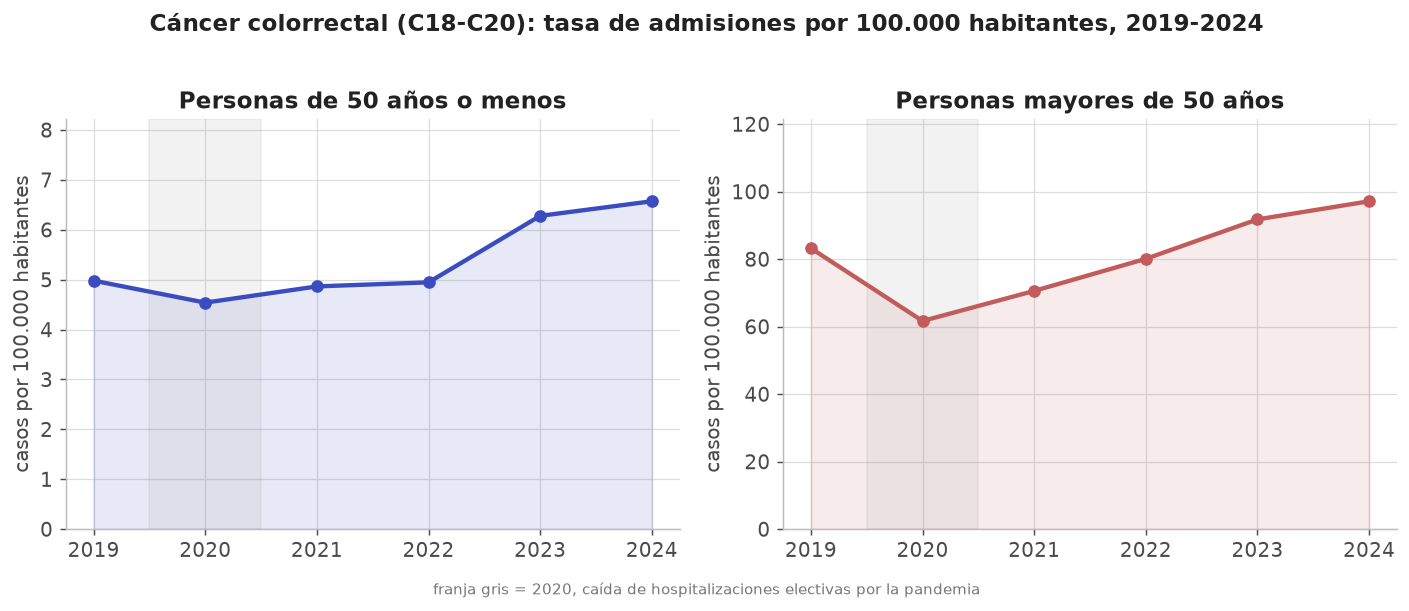

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for ax, grupo, color, titulo in zip(
    axes, ["menor o igual a 50", "mayor a 50"], [PALETA[0], PALETA[3]],
    ["Personas de 50 años o menos", "Personas mayores de 50 años"]
):
    sub = tasas[tasas.grupo_edad == grupo].sort_values("anio")
    ax.plot(sub.anio, sub.tasa_por_100k, marker="o", color=color, linewidth=2.4, markersize=6)
    ax.fill_between(sub.anio, sub.tasa_por_100k, alpha=0.12, color=color)
    ax.set_title(titulo)
    ax.set_ylabel("casos por 100.000 habitantes")
    ax.set_ylim(0, sub.tasa_por_100k.max() * 1.25)
    ax.set_xticks(sub.anio)
    ax.axvspan(2019.5, 2020.5, color="#999999", alpha=0.12)
fig.suptitle("Cáncer colorrectal (C18-C20): tasa de admisiones por 100.000 habitantes, 2019-2024",
             fontsize=12.5, fontweight="bold", y=1.02)
fig.text(0.5, -0.02, "franja gris = 2020, caída de hospitalizaciones electivas por la pandemia",
          ha="center", fontsize=8.5, color="#777777")
fig.tight_layout()
plt.show()

**2020 es un quiebre en ambos grupos**, no una tendencia real: coincide con la
pandemia, cuando cayeron fuertemente las hospitalizaciones electivas y las colonoscopías
de pesquisa. Cualquier comparación que use 2019 o 2020 como punto de partida corre el
riesgo de confundir "recuperación pos-pandemia" con "aumento de la enfermedad". Por eso
el resto del análisis reporta el crecimiento de dos formas: 2019→2024 (el período
completo) y 2021→2024 (que evita el quiebre).

In [3]:
resumen = au.resumen_crecimiento(tasas)
resumen_fmt = resumen.copy()
for c in resumen_fmt.columns:
    if "cagr" in c or "cambio" in c:
        resumen_fmt[c] = (resumen_fmt[c] * 100).round(1).astype(str) + "%"
    elif "tasa" in c:
        resumen_fmt[c] = resumen_fmt[c].round(2)
resumen_fmt

,grupo_edad,tasa_2019,tasa_2021,tasa_2024,cagr_2019_2024,cambio_total_2019_2024,cagr_2021_2024,cambio_total_2021_2024
0,mayor a 50,83.24,70.60,97.17,3.1%,16.7%,11.2%,37.6%
1,menor o igual a 50,4.98,4.87,6.57,5.7%,31.9%,10.5%,35.1%


## 2. ¿Quién crece más rápido? Depende de qué años se comparen, y esa honestidad importa

Se indexa cada serie a 2019 = 100 para comparar la *velocidad* de crecimiento en una
misma escala, sin importar que la tasa base de los mayores de 50 sea ~17 veces más alta.

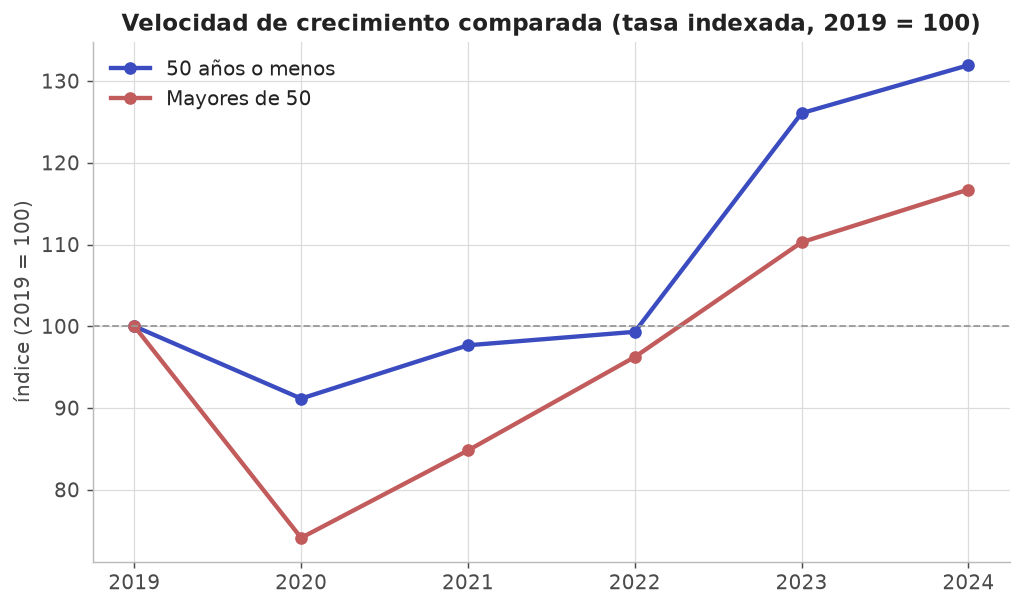

In [4]:
idx = au.indice_base_2019(tasas)
fig, ax = plt.subplots(figsize=(8, 4.8))
for grupo, color in zip(["menor o igual a 50", "mayor a 50"], [PALETA[0], PALETA[3]]):
    sub = idx[idx.grupo_edad == grupo].sort_values("anio")
    ax.plot(sub.anio, sub.indice, marker="o", color=color, linewidth=2.4, markersize=6,
            label="50 años o menos" if "menor" in grupo else "Mayores de 50")
ax.axhline(100, color="#999999", linewidth=1, linestyle="--")
ax.set_title("Velocidad de crecimiento comparada (tasa indexada, 2019 = 100)")
ax.set_ylabel("índice (2019 = 100)")
ax.set_xticks(sorted(idx.anio.unique()))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

**2019→2024 (el período completo):** la tasa en personas de 50 años o menos subió
**31,9%** (de 4,98 a 6,57 por 100.000), casi el doble que el **16,7%** de los mayores de
50 (de 83,2 a 97,2 por 100.000). En velocidad anual compuesta (CAGR), eso es 5,7% anual
en el grupo joven contra 3,1% en el grupo mayor.

**2021→2024 (evitando el quiebre de 2020):** acá la historia cambia. Ambos grupos crecen
a un ritmo casi idéntico, alrededor de 10,5-11,2% anual compuesto. Gran parte del salto
2022→2023 que se ve en el gráfico (696 → 883 casos en el grupo joven, 4.615 → 5.416 en
el grupo mayor) ocurre **en los dos grupos a la vez**, lo que apunta más a una
recuperación general del sistema hospitalario pos-pandemia que a algo específico de
cáncer colorrectal en jóvenes.

**Conclusión honesta de esta sección:** sí hay una tendencia al alza más marcada en
personas de 50 años o menos cuando se mira el período completo 2019-2024, pero una parte
de esa brecha se explica por el desplome desigual de 2020 (las hospitalizaciones de los
mayores de 50 cayeron más que las de los jóvenes ese año, así que su "recuperación"
después se ve más pronunciada). La curva de mayor pendiente en el grupo joven, sin
embargo, se mantiene incluso comparando 2021→2024, solo que la diferencia con el grupo
mayor se reduce a un empate estadístico dado el tamaño de la muestra.

## 3. Perfil de los casos en personas de 50 años o menos

4.508 admisiones en total (2019-2024). ¿A qué edad, y en quiénes?

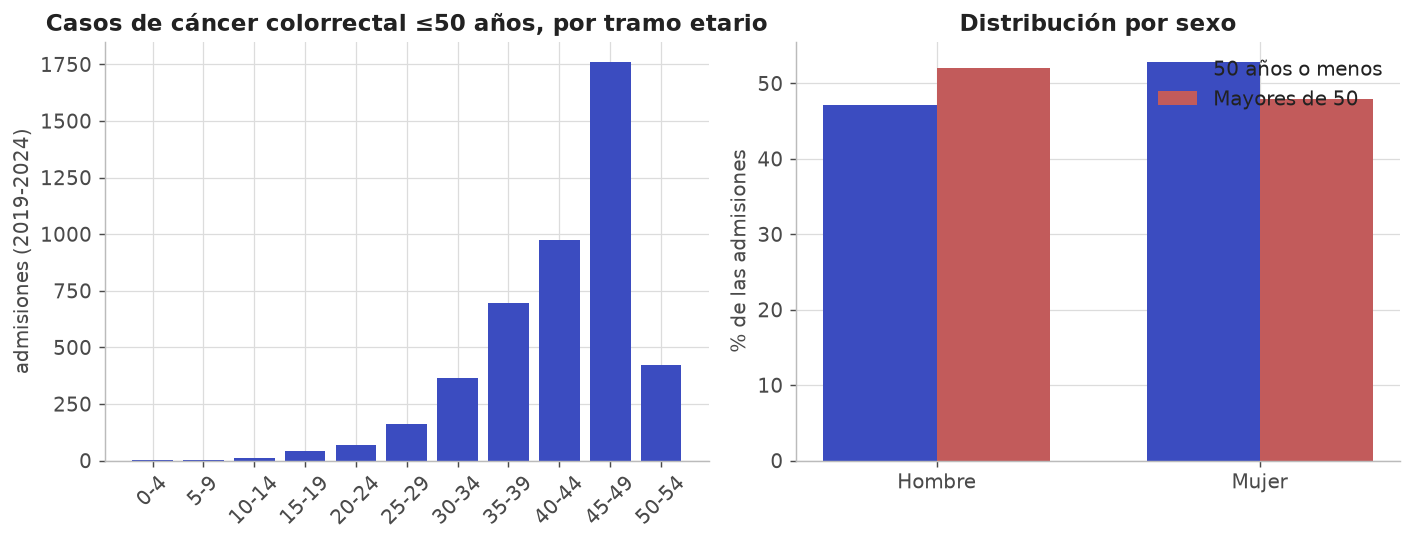

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
dist = au.distribucion_edad_jovenes(df)
axes[0].bar([f"{int(t)}-{int(t)+4}" for t in dist.index], dist.values, color=PALETA[0])
axes[0].set_title("Casos de cáncer colorrectal ≤50 años, por tramo etario")
axes[0].set_ylabel("admisiones (2019-2024)")
axes[0].tick_params(axis="x", rotation=45)

sexo = au.por_sexo(df) * 100
x = np.arange(2); width = 0.35
for i, (grupo, color) in enumerate(zip(["menor o igual a 50", "mayor a 50"], [PALETA[0], PALETA[3]])):
    vals = [sexo.loc[grupo, "HOMBRE"], sexo.loc[grupo, "MUJER"]]
    axes[1].bar(x + i * width, vals, width, color=color,
                label="50 años o menos" if "menor" in grupo else "Mayores de 50")
axes[1].set_xticks(x + width / 2)
axes[1].set_xticklabels(["Hombre", "Mujer"])
axes[1].set_ylabel("% de las admisiones")
axes[1].set_title("Distribución por sexo")
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

El 70% de los casos "jóvenes" se concentra entre los 40 y 49 años: la definición de
"early-onset" (≤50) no significa que el cáncer colorrectal sea frecuente en adultos de 20
o 30 años, sigue siendo raro ahí. Es sobre todo un corrimiento de la última década de vida
antes de los 50 hacia abajo. Por sexo, la distribución es prácticamente pareja en ambos
grupos etarios (52,9% mujeres en el grupo joven contra 47,9% en el grupo mayor), sin una
brecha relevante que investigar por esta vía.

## 4. Cómo llega el paciente al hospital, y dónde aparece el tumor

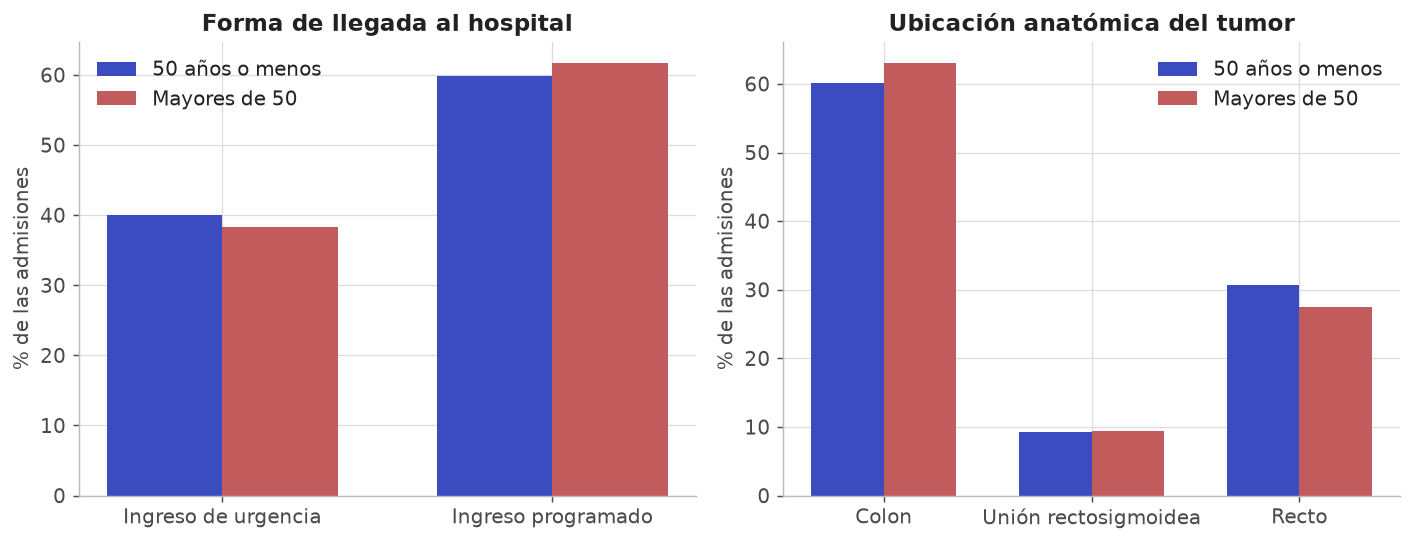

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
ingreso = au.por_tipo_ingreso(df) * 100
x = np.arange(2); width = 0.35
for i, (grupo, color) in enumerate(zip(["menor o igual a 50", "mayor a 50"], [PALETA[0], PALETA[3]])):
    vals = [ingreso.loc[grupo, "URGENCIA"], ingreso.loc[grupo, "PROGRAMADA"]]
    axes[0].bar(x + i * width, vals, width, color=color,
                label="50 años o menos" if "menor" in grupo else "Mayores de 50")
axes[0].set_xticks(x + width / 2)
axes[0].set_xticklabels(["Ingreso de urgencia", "Ingreso programado"])
axes[0].set_ylabel("% de las admisiones")
axes[0].set_title("Forma de llegada al hospital")
axes[0].legend(frameon=False)

sub = au.por_subsitio(df) * 100
etiquetas = {"C18": "Colon", "C19": "Unión rectosigmoidea", "C20": "Recto"}
x = np.arange(3)
for i, (grupo, color) in enumerate(zip(["menor o igual a 50", "mayor a 50"], [PALETA[0], PALETA[3]])):
    vals = [sub.loc[grupo, c] for c in ["C18", "C19", "C20"]]
    axes[1].bar(x + i * width, vals, width, color=color,
                label="50 años o menos" if "menor" in grupo else "Mayores de 50")
axes[1].set_xticks(x + width / 2)
axes[1].set_xticklabels([etiquetas[c] for c in ["C18", "C19", "C20"]])
axes[1].set_ylabel("% de las admisiones")
axes[1].set_title("Ubicación anatómica del tumor")
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

Dos señales, ambas modestas en magnitud pero en la dirección que reporta la
literatura internacional sobre cáncer colorrectal de aparición temprana:

- **Más ingresos de urgencia** en el grupo joven (40,1% contra 38,3%). Consistente con
  diagnóstico más tardío: en personas de 50 años o menos no hay tamizaje poblacional
  sistemático en Chile (empieza a los 50), así que muchos casos se detectan recién cuando
  el paciente llega con síntomas agudos.
- **Más tumores rectales** en el grupo joven (30,7% contra 27,5% en recto, y algo menos
  en colon: 60,1% contra 63,0%). El corrimiento hacia el lado izquierdo/recto en pacientes
  jóvenes está documentado en estudios internacionales.

Ninguna de las dos diferencias es enorme, pero ambas apuntan en la misma dirección que la
hipótesis de "diagnóstico más tardío en jóvenes por falta de tamizaje", no en contra.

## 5. Letalidad intrahospitalaria

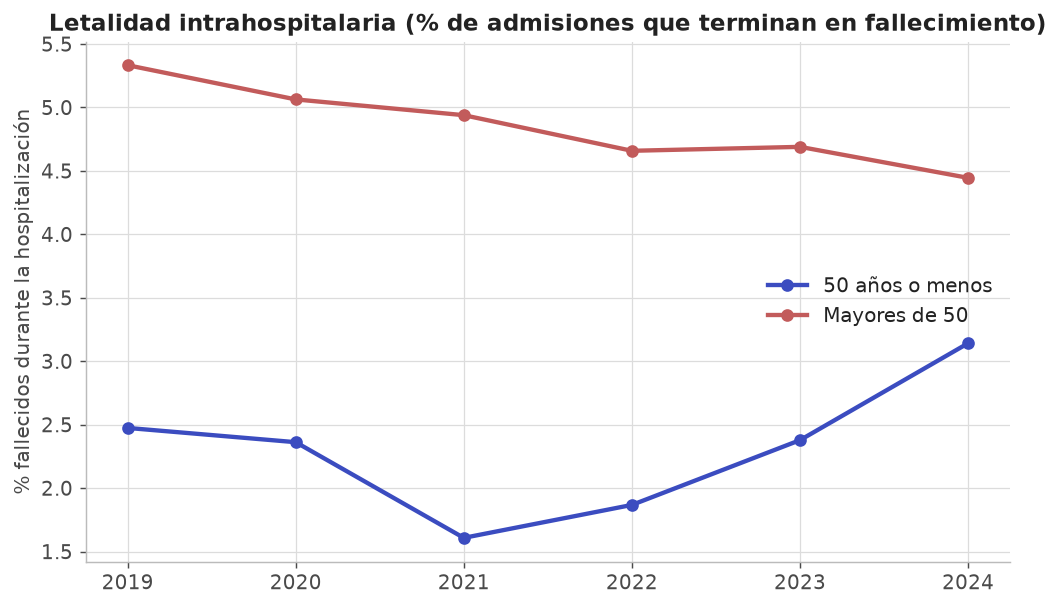

In [7]:
let = au.letalidad_por_anio(df) * 100
fig, ax = plt.subplots(figsize=(8, 4.8))
for grupo, color in zip(["menor o igual a 50", "mayor a 50"], [PALETA[0], PALETA[3]]):
    ax.plot(let.index, let[grupo], marker="o", color=color, linewidth=2.4, markersize=6,
            label="50 años o menos" if "menor" in grupo else "Mayores de 50")
ax.set_title("Letalidad intrahospitalaria (% de admisiones que terminan en fallecimiento)")
ax.set_ylabel("% fallecidos durante la hospitalización")
ax.set_xticks(sorted(let.index))
ax.legend(frameon=False, loc="center right")
fig.tight_layout()
plt.show()

In [8]:
jov = au.crc(df)[au.crc(df).grupo_edad == "menor o igual a 50"].copy()
jov["fallecido"] = (jov.tipo_alta == "FALLECIDO").astype(int)
jov.groupby("anio")["fallecido"].agg(admisiones="size", fallecidos="sum")

,admisiones,fallecidos
anio,,
2019,687,17
2020,635,15
2021,684,11
2022,696,13
2023,883,21
2024,923,29


La letalidad es, como es esperable, menor en el grupo joven en todos los años
(menos comorbilidad de base). Pero llama la atención que **viene subiendo desde 2021**
(1,6% → 3,1%), mientras que en el grupo mayor sigue bajando (5,3% → 4,4%). Dicho eso, el
grupo joven tiene pocas muertes en total por año (11 a 29), así que un par de casos de
diferencia mueve el porcentaje varios puntos. Esta señal es sugerente pero no
concluyente con este tamaño de muestra: no se puede afirmar con estos datos que la
letalidad esté empeorando en jóvenes, solo que no se puede descartar y merece
seguimiento con más años de datos.

## 6. La pregunta que más importa: ¿sube el cáncer real, o solo la pesquisa?

Un aumento en los diagnósticos podría significar dos cosas muy distintas: más gente
enfermando de cáncer invasor, o simplemente más tamizaje detectando lesiones tempranas
(pólipos, carcinoma in situ) que antes pasaban inadvertidas. Para distinguirlas, se
compara la evolución de ambas categorías **dentro del mismo grupo joven**.

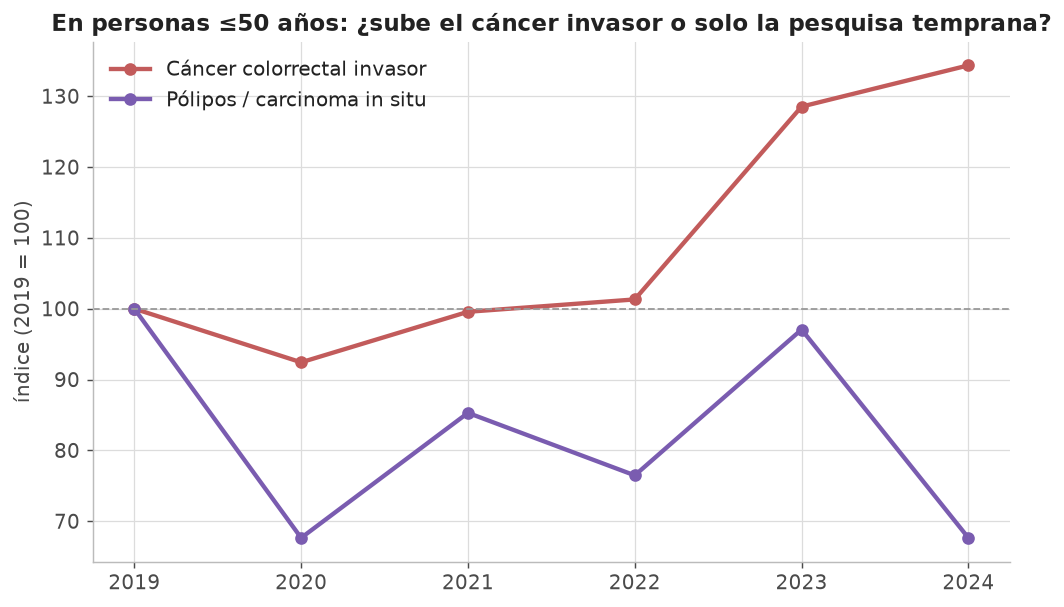

,cancer_invasor,polipo_o_in_situ,indice_cancer_invasor,indice_polipo_o_in_situ
anio,,,,
2019,687,34,100.000000,100.000000
2020,635,23,92.430859,67.647059
2021,684,29,99.563319,85.294118
2022,696,26,101.310044,76.470588
2023,883,33,128.529840,97.058824
2024,923,23,134.352256,67.647059


In [9]:
comp = au.polipos_in_situ_vs_invasor_jovenes(df)
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(comp.index, comp["indice_cancer_invasor"], marker="o", color=PALETA[3],
         linewidth=2.4, markersize=6, label="Cáncer colorrectal invasor")
ax.plot(comp.index, comp["indice_polipo_o_in_situ"], marker="o", color=PALETA[4],
         linewidth=2.4, markersize=6, label="Pólipos / carcinoma in situ")
ax.axhline(100, color="#999999", linewidth=1, linestyle="--")
ax.set_title("En personas ≤50 años: ¿sube el cáncer invasor o solo la pesquisa temprana?")
ax.set_ylabel("índice (2019 = 100)")
ax.set_xticks(comp.index)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()
comp

**Este es el hallazgo más importante del análisis.** Si el aumento fuera producto
de más tamizaje, se esperaría ver crecer *también*, o incluso más, los diagnósticos de
pólipos adenomatosos y carcinoma in situ (las lesiones que la pesquisa está diseñada para
encontrar antes de que se conviertan en cáncer invasor). Ocurre lo contrario: mientras el
cáncer invasor sube 34,4% entre 2019 y 2024, los diagnósticos de pólipos/in situ en el
mismo grupo etario **caen 32,4%**.

Esto no favorece la hipótesis de "estamos pesquisando mejor y por eso aparecen más
casos". Favorece la hipótesis de que hay más cáncer colorrectal invasor apareciendo en
personas de 50 años o menos, detectado tarde (cuando ya es invasor y sintomático), no
temprano (cuando todavía es un pólipo o una lesión in situ). Es consistente con la señal
de la sección 4: más ingresos de urgencia, más enfermedad ya establecida al momento del
diagnóstico.

**Nota de tamaño de muestra:** los pólipos/in situ en el grupo joven son entre 23 y 34
casos por año, una base pequeña donde un año atípico pesa mucho. La caída es marcada y
consistente (2024 es el valor más bajo de la serie), pero conviene no sobre-interpretar
un solo año cualquiera dentro de esa serie.

## 7. Categorías relacionadas, aparte: cáncer de ano

El cáncer de ano y del conducto anal (CIE-10 C21) es anatómicamente vecino, pero tiene un
perfil de causa distinto (asociado principalmente a VPH), así que se reporta aparte y no
se suma al total de cáncer colorrectal.

In [10]:
ano = df[df.categoria_clinica == "cancer_ano"]
ano.groupby(["anio", "grupo_edad"]).size().unstack()

grupo_edad,mayor a 50,menor o igual a 50
anio,,
2019,164,41
2020,99,38
2021,81,27
2022,133,28
2023,110,46
2024,155,41


A diferencia del cáncer colorrectal, el cáncer de ano en personas de 50 años o
menos **no muestra una tendencia clara** en este período (41 casos en 2019, 41 en 2024,
con oscilación entre medio). Con series tan cortas y bases tan chicas, no se puede sacar
una conclusión sobre esta categoría específicamente, más allá de que no repite el patrón
de aumento sostenido que sí se ve en cáncer colorrectal.

## Conclusiones

1. **La tasa de cáncer colorrectal por 100.000 habitantes subió en ambos grupos etarios
   entre 2019 y 2024**, pero más en personas de 50 años o menos (+31,9%) que en mayores
   de 50 (+16,7%). Usando 2021 como base, para evitar el quiebre de la pandemia, el
   crecimiento es parecido entre ambos grupos (~10-11% anual compuesto), así que buena
   parte del salto reciente es una recuperación general del sistema, no algo exclusivo de
   los jóvenes. Aun así, la brecha del período completo (2019-2024) sigue siendo real.

2. **El hallazgo más sólido es indirecto: en jóvenes, el cáncer invasor sube 34% mientras
   los diagnósticos de pólipos/carcinoma in situ caen 32%.** Esto descarta que el aumento
   se explique por más tamizaje temprano, y es más compatible con que hay más cáncer
   colorrectal real apareciendo, y detectado en etapa invasora.

3. **Los jóvenes con cáncer colorrectal llegan más por urgencia** (40,1% contra 38,3%) y
   **con más tumores rectales** (30,7% contra 27,5%), ambas señales, modestas pero
   consistentes, de un diagnóstico más tardío. En Chile el tamizaje poblacional para
   cáncer colorrectal empieza a los 50 años, así que en personas más jóvenes casi todo
   el diagnóstico depende de que aparezcan síntomas.

4. **El 70% de los casos "jóvenes" se concentra entre los 40 y 49 años.** El cáncer
   colorrectal antes de los 30 sigue siendo raro en estos datos; el fenómeno es
   sobre todo un corrimiento hacia la última década antes de los 50, no una explosión en
   adultos jóvenes propiamente tal.

5. **La letalidad intrahospitalaria en jóvenes viene subiendo desde 2021** (1,6% → 3,1%)
   mientras baja en el grupo mayor, pero con una base de 11 a 29 muertes por año: es una
   señal a seguir, no una conclusión firme con estos datos.

**En una frase:** los datos de GRD no muestran una "explosión" abrupta y aislada en
jóvenes, pero sí una tendencia de fondo sostenida y varias señales indirectas
(tamizaje, forma de llegada, ubicación del tumor) que apuntan en la misma dirección que
la alerta de la comunidad médica: más cáncer colorrectal real en personas de 50 años o
menos, probablemente detectado tarde por la ausencia de tamizaje poblacional en ese
tramo etario.

## Cómo reproducir este análisis

```bash
python3 -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt

# 1. Extraer los datos desde las bases GRD crudas (requiere tenerlas localmente)
export GRD_DIR="/ruta/a/bases de datos GRD"
python3 src/extract_data.py

# 2. Descargar y agregar la población del INE (denominador de las tasas)
python3 src/extraer_poblacion.py

# 3. Generar las figuras estáticas y los GIFs animados
python3 src/generar_figuras_estaticas.py
python3 src/generar_gifs.py
```

Los archivos GRD crudos (varios GB por año) se descargan del
[portal de datos abiertos de FONASA](https://datosabiertos.fonasa.cl/), y no se incluyen en este
repositorio. El parquet ya procesado (`data/crc_admisiones.parquet`, ~500 KB) sí se
incluye, para que el notebook se pueda ejecutar sin descargar nada. El cuadro de población
del INE (~11 MB) tampoco se incluye: `src/extraer_poblacion.py` lo descarga solo.
